<div style="
    display: flex;
    justify-content: space-between;
    align-items: center;
    padding: 30px 40px ;
    background-color: #ffffff;
    border-radius: 12px;
    box-shadow: 0 4px 12px rgba(0,0,0,0.08);
    margin-bottom: 20px;
">
    <img 
        src="https://raw.githubusercontent.com/sarasadatnasr/Machine_Learning_Final_Project/728689a356aa43073d6552462b8ba6ab8aca9218/Logo/ut-logo.png"
        alt="University Logo"
        style="height: 120px;"
    >
    <div style="
        text-align: center;
        font-family: 'Segoe UI', Arial, sans-serif;
        color: #222;
        line-height: 1.4;
    ">
        <h1 style="margin: 0; font-size: 32px; color: #2e98c6;">Machine Learning - Final Project</h1>
        <h3 style="margin: 6px 0 12px; font-weight: 500; color: #555;">Data Cleaning and Feature Extraction</h3>
        <p style="margin: 0; font-size: 15px;">
            <strong>Sara Sadat Nasr Azadani</strong> ·
            <strong>Alireza Farshi</strong> ·
            <strong>Saeid Rezaie</strong>
        </p>
    </div>
    <img 
        src="https://github.com/sarasadatnasr/Machine_Learning_Final_Project/blob/138c1e786d169810ea14a38a1d2804169ee6b307/Logo/co-w-9.png"
        alt="Faculty Logo"
        style="height: 120px;"
    >
</div>

<div style="
    display: flex;
    justify-content: space-between;
    align-items: center;
    padding: 30px 40px ;
    background-color: #ffffff;
    border-radius: 12px;
    box-shadow: 0 4px 12px rgba(0,0,0,0.08);
    margin-bottom: 20px;
    color: #555;
    font-size: 20px;
">
📚Import Libraries
</div>

In [1]:
import os
import numpy as np
import pandas as pd
import librosa
import librosa.display
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import warnings
from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D

<div style="
    display: flex;
    justify-content: space-between;
    align-items: center;
    padding: 30px 40px ;
    background-color: #ffffff;
    border-radius: 12px;
    box-shadow: 0 4px 12px rgba(0,0,0,0.08);
    margin-bottom: 20px;
    color: #555;
    font-size: 20px;
">
🎨 Set Environments theme
</div>

In [2]:
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

<div style="
    display: flex;
    justify-content: space-between;
    align-items: center;
    padding: 30px 40px ;
    background-color: #ffffff;
    border-radius: 12px;
    box-shadow: 0 4px 12px rgba(0,0,0,0.08);
    margin-bottom: 20px;
    color: #555;
    font-size: 20px;
">
📁 Define paths or Create them
</div>

In [3]:
BASE_PATH = "Datasets"
LANGUAGES = ["German", "Italian", "Korean", "Spanish"]
GENDERS = ["Female", "Male"]

for lang in LANGUAGES:
    for gender in GENDERS:
        os.makedirs(os.path.join(BASE_PATH, lang, gender), exist_ok=True)

<div style="
    display: flex;
    justify-content: space-between;
    align-items: center;
    padding: 30px 40px ;
    background-color: #ffffff;
    border-radius: 12px;
    box-shadow: 0 4px 12px rgba(0,0,0,0.08);
    margin-bottom: 20px;
    color: #555;
    font-size: 20px;
">
🗄️ Function to load and explore dataset statistics
</div>

In [4]:
def explore_dataset():
    data_info = []
    
    for lang in LANGUAGES:
        for gender in GENDERS:
            path = os.path.join(BASE_PATH, lang, gender)
            if os.path.exists(path):
                files = [f for f in os.listdir(path) if f.endswith('.mp3')]
                for file in files:
                    file_path = os.path.join(path, file)
                    try:
                        # Load audio file - FIXED: removed duration parameter to get full duration
                        y, sr = librosa.load(file_path, sr=None)  # Removed: duration=10
                        duration = librosa.get_duration(y=y, sr=sr)
                        
                        data_info.append({
                            'language': lang,
                            'gender': gender,
                            'filename': file,
                            'duration': duration,
                            'sample_rate': sr,
                            'num_samples': len(y)
                        })
                    except Exception as e:
                        print(f"Error loading {file_path}: {e}")
    
    return pd.DataFrame(data_info)


# Explore dataset
print("Exploring dataset structure...")
df_info = explore_dataset()

# Display basic statistics
print(f"\nTotal files: {len(df_info)}")
print("\nDistribution by language:")
print(df_info['language'].value_counts())
print("\nDistribution by gender:")
print(df_info['gender'].value_counts())

Exploring dataset structure...

Total files: 712

Distribution by language:
language
Italian    180
Korean     180
Spanish    180
German     172
Name: count, dtype: int64

Distribution by gender:
gender
Female    360
Male      352
Name: count, dtype: int64


<div style="
    display: flex;
    justify-content: space-between;
    align-items: center;
    padding: 30px 40px ;
    background-color: #ffffff;
    border-radius: 12px;
    box-shadow: 0 4px 12px rgba(0,0,0,0.08);
    margin-bottom: 20px;
    color: #555;
    font-size: 20px;
">
📊 Visualize dataset distribution
</div>

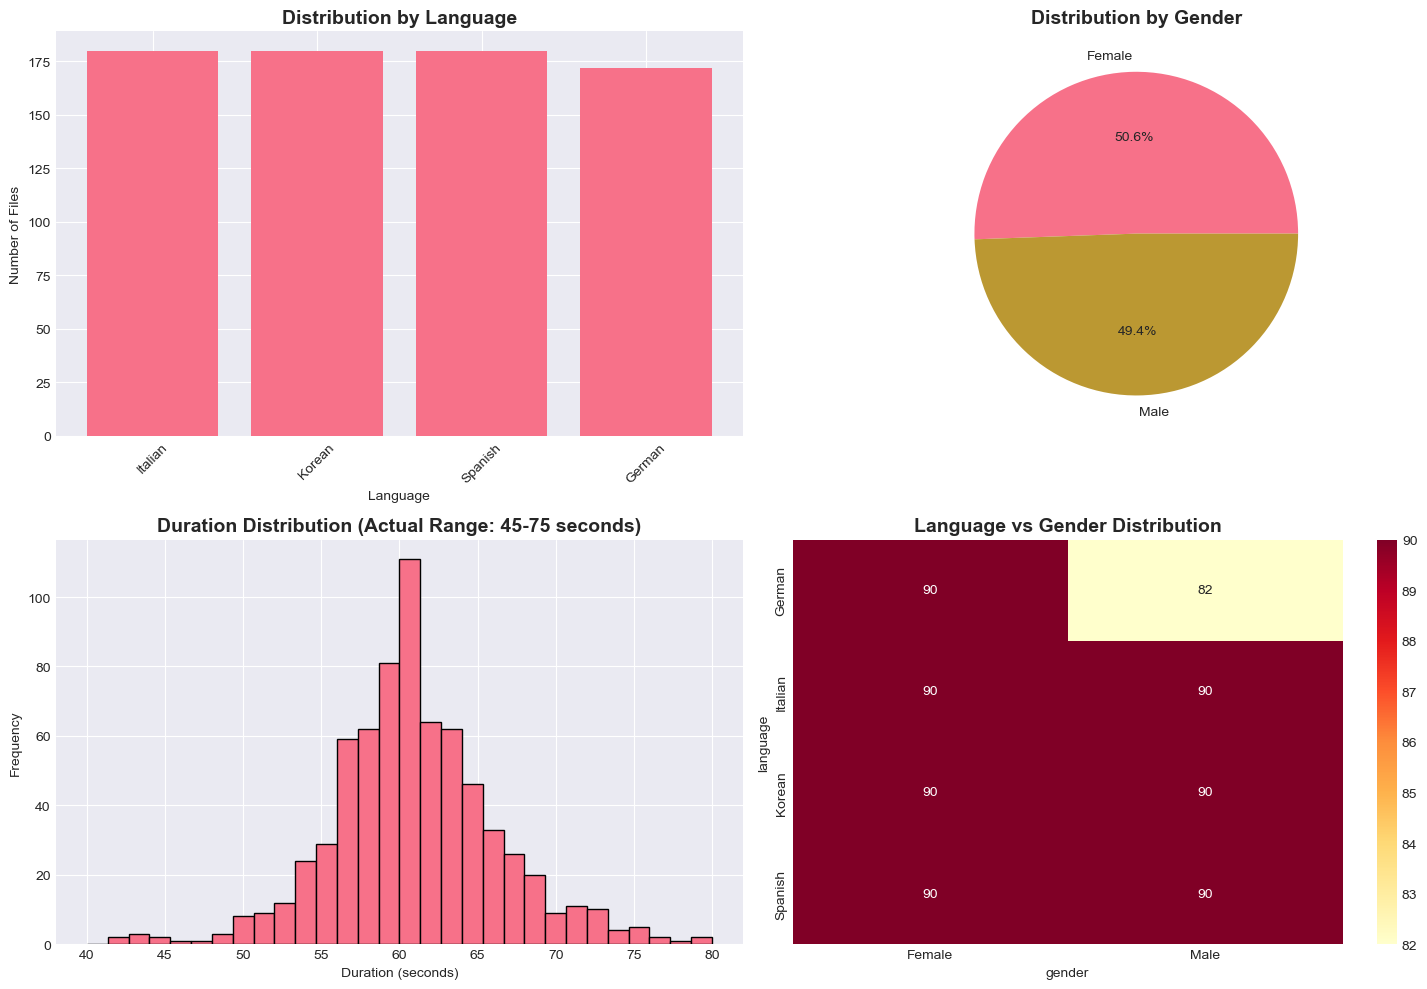

In [5]:
# Visualize dataset distribution
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Language distribution
lang_counts = df_info['language'].value_counts()
axes[0,0].bar(lang_counts.index, lang_counts.values)
axes[0,0].set_title('Distribution by Language', fontsize=14, fontweight='bold')
axes[0,0].set_xlabel('Language')
axes[0,0].set_ylabel('Number of Files')
axes[0,0].tick_params(axis='x', rotation=45)

# Gender distribution
gender_counts = df_info['gender'].value_counts()
axes[0,1].pie(gender_counts.values, labels=gender_counts.index, autopct='%1.1f%%')
axes[0,1].set_title('Distribution by Gender', fontsize=14, fontweight='bold')

# Duration distribution - FIXED: adjusted bins for 45-75 second range
axes[1,0].hist(df_info['duration'], bins=30, edgecolor='black', range=(40, 80))
axes[1,0].set_title('Duration Distribution (Actual Range: 45-75 seconds)', fontsize=14, fontweight='bold')
axes[1,0].set_xlabel('Duration (seconds)')
axes[1,0].set_ylabel('Frequency')

# Language vs Gender heatmap
cross_tab = pd.crosstab(df_info['language'], df_info['gender'])
sns.heatmap(cross_tab, annot=True, fmt='d', cmap='YlOrRd', ax=axes[1,1])
axes[1,1].set_title('Language vs Gender Distribution', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('./Data_Cleaning_and_Feature_Extraction/dataset_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

<div style="
    display: flex;
    justify-content: space-between;
    align-items: center;
    padding: 30px 40px ;
    background-color: #ffffff;
    border-radius: 12px;
    box-shadow: 0 4px 12px rgba(0,0,0,0.08);
    margin-bottom: 20px;
    color: #555;
    font-size: 20px;
">
🗣️ Audio Preprocessing and Visualization
</div>

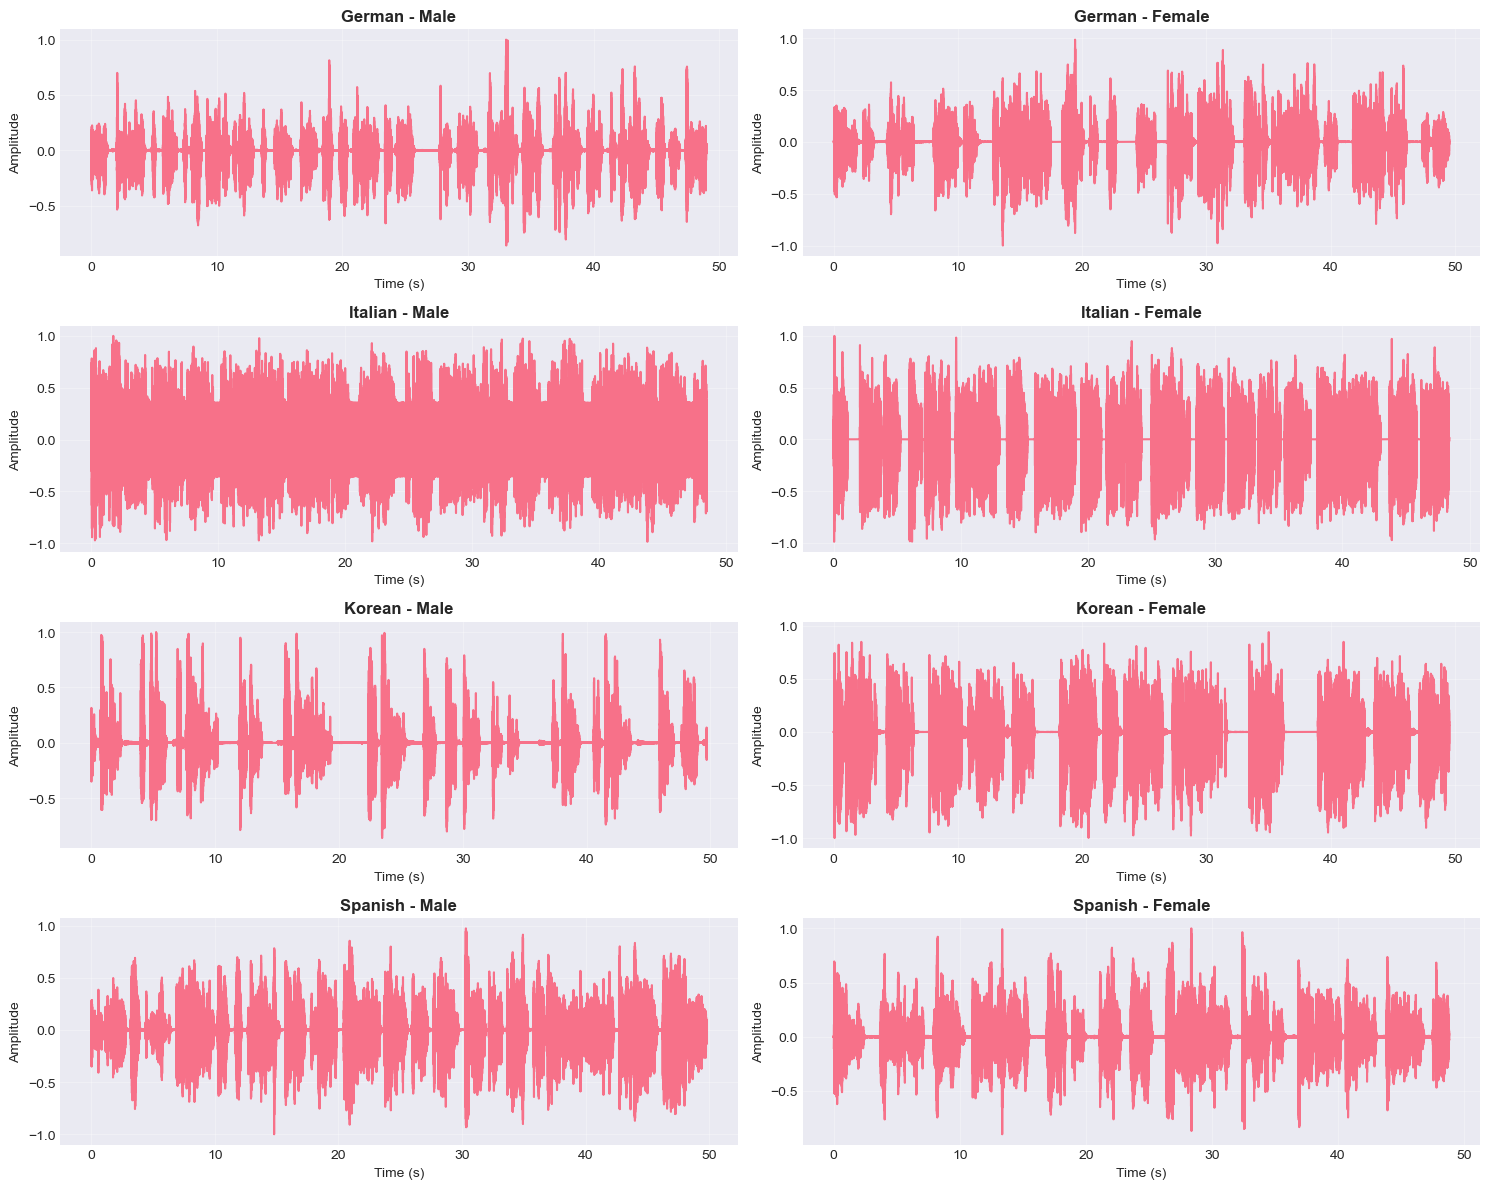

In [6]:
def preprocess_audio(file_path, target_sr=22050, duration=50):
    try:
        y, sr = librosa.load(file_path, sr=target_sr, duration=duration)        
        # Remove silence
        y_trimmed, _ = librosa.effects.trim(y, top_db=20)
        
        # Normalize audio
        y_normalized = librosa.util.normalize(y_trimmed)
        
        return y_normalized, sr
        
    except Exception as e:
        print(f"Error processing {file_path}: {e}")
        return None, None


def augment_audio(y, sr):
    augmented = []
    # Add white noise
    noise = np.random.randn(len(y)) * 0.005
    y_noise = y + noise
    augmented.append(y_noise)
    
    # Time stretching
    y_stretch = librosa.effects.time_stretch(y, rate=0.9)
    augmented.append(y_stretch)
    
    # Pitch shifting
    y_pitch = librosa.effects.pitch_shift(y, sr=sr, n_steps=2)
    augmented.append(y_pitch)
    return augmented



def plot_audio_waveforms():
    fig, axes = plt.subplots(4, 2, figsize=(15, 12))
    
    for idx, lang in enumerate(LANGUAGES):
        # Find one male and one female sample
        male_samples = df_info[(df_info['language'] == lang) & (df_info['gender'] == 'Male')]
        female_samples = df_info[(df_info['language'] == lang) & (df_info['gender'] == 'Female')]

        samples_to_plot = []
        
        # Add male sample if available
        if len(male_samples) > 0:
            samples_to_plot.append(male_samples.iloc[0])
        elif len(female_samples) > 1:
            # If no male, use second female sample
            samples_to_plot.append(female_samples.iloc[1])
        
        # Add female sample if available
        if len(female_samples) > 0:
            samples_to_plot.append(female_samples.iloc[0])
        elif len(male_samples) > 1:
            # If no female, use second male sample
            samples_to_plot.append(male_samples.iloc[1])
        
        # Make sure we have exactly 2 samples
        if len(samples_to_plot) < 2:
            # Fill with any available sample
            all_samples = df_info[df_info['language'] == lang]
            while len(samples_to_plot) < 2 and len(samples_to_plot) < len(all_samples):
                next_sample = all_samples.iloc[len(samples_to_plot)]
                samples_to_plot.append(next_sample)
        
        for j, row in enumerate(samples_to_plot[:2]):  # Plot max 2 samples
            file_path = os.path.join(BASE_PATH, row['language'], row['gender'], row['filename'])
            y, sr = preprocess_audio(file_path, duration=50)
            
            if y is not None:
                axes[idx, j].plot(np.linspace(0, len(y)/sr, len(y)), y)
                axes[idx, j].set_title(f'{lang} - {row["gender"]}', fontweight='bold')
                axes[idx, j].set_xlabel('Time (s)')
                axes[idx, j].set_ylabel('Amplitude')
                axes[idx, j].grid(True, alpha=0.3)
            else:
                # Handle case where audio couldn't be loaded
                axes[idx, j].text(0.5, 0.5, 'Audio Load Error', 
                                  ha='center', va='center', transform=axes[idx, j].transAxes)
                axes[idx, j].set_title(f'{lang} - {row["gender"]} (Error)', fontweight='bold')
                axes[idx, j].set_xlabel('Time (s)')
                axes[idx, j].set_ylabel('Amplitude')
                axes[idx, j].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('./Data_Cleaning_and_Feature_Extraction/audio_waveforms.png', dpi=300, bbox_inches='tight')
    plt.show()

plot_audio_waveforms()

<div style="
    display: flex;
    justify-content: space-between;
    align-items: center;
    padding: 30px 40px ;
    background-color: #ffffff;
    border-radius: 12px;
    box-shadow: 0 4px 12px rgba(0,0,0,0.08);
    margin-bottom: 20px;
    color: #555;
    font-size: 20px;
">
🔑 Feature Extraction
</div>

In [ ]:
def extract_features(y, sr, n_mfcc=20, n_chroma=12, n_mels=128):
    features = {}
    
    # Time-domain features
    features['zcr_mean'] = np.mean(librosa.feature.zero_crossing_rate(y))
    features['zcr_std'] = np.std(librosa.feature.zero_crossing_rate(y))
    
    # Root Mean Square Energy
    rms = librosa.feature.rms(y=y)
    features['rms_mean'] = np.mean(rms)
    features['rms_std'] = np.std(rms)
    
    # Spectral Centroid
    spectral_centroid = librosa.feature.spectral_centroid(y=y, sr=sr)
    features['spectral_centroid_mean'] = np.mean(spectral_centroid)
    features['spectral_centroid_std'] = np.std(spectral_centroid)
    
    # Spectral Bandwidth
    spectral_bandwidth = librosa.feature.spectral_bandwidth(y=y, sr=sr)
    features['spectral_bandwidth_mean'] = np.mean(spectral_bandwidth)
    features['spectral_bandwidth_std'] = np.std(spectral_bandwidth)
    
    # Spectral Rolloff
    spectral_rolloff = librosa.feature.spectral_rolloff(y=y, sr=sr)
    features['spectral_rolloff_mean'] = np.mean(spectral_rolloff)
    features['spectral_rolloff_std'] = np.std(spectral_rolloff)
    
    # Mel-Frequency Cepstral Coefficients (MFCCs) - Most important for speech
    mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)
    for i in range(n_mfcc):
        features[f'mfcc_{i}_mean'] = np.mean(mfccs[i])
        features[f'mfcc_{i}_std'] = np.std(mfccs[i])
    
    #  Chroma features (for pitch analysis)
    chroma = librosa.feature.chroma_stft(y=y, sr=sr, n_chroma=n_chroma)
    for i in range(n_chroma):
        features[f'chroma_{i}_mean'] = np.mean(chroma[i])
        features[f'chroma_{i}_std'] = np.std(chroma[i])
    
    # Mel-scaled spectrogram
    mel_spec = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=n_mels)
    mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)
    features['mel_spec_mean'] = np.mean(mel_spec_db)
    features['mel_spec_std'] = np.std(mel_spec_db)
    
    # Tonnetz features (tonal centroid features)
    tonnetz = librosa.feature.tonnetz(y=y, sr=sr)
    for i in range(6):
        features[f'tonnetz_{i}_mean'] = np.mean(tonnetz[i])
        features[f'tonnetz_{i}_std'] = np.std(tonnetz[i])
    
    # Spectral contrast
    spectral_contrast = librosa.feature.spectral_contrast(y=y, sr=sr)
    for i in range(spectral_contrast.shape[0]):
        features[f'spectral_contrast_{i}_mean'] = np.mean(spectral_contrast[i])
        features[f'spectral_contrast_{i}_std'] = np.std(spectral_contrast[i])
    
    # Poly features
    poly_features = librosa.feature.poly_features(y=y, sr=sr)
    features['poly_0_mean'] = np.mean(poly_features[0])  # coefficient 0
    features['poly_1_mean'] = np.mean(poly_features[1])  # coefficient 1
    
    # Tempogram (rhythm features)
    onset_env = librosa.onset.onset_strength(y=y, sr=sr)
    tempogram = librosa.feature.tempogram(onset_envelope=onset_env, sr=sr)
    features['tempogram_mean'] = np.mean(tempogram)
    features['tempogram_std'] = np.std(tempogram)
    
    return features


def extract_all_features():
    all_features = []
    all_labels = []
    all_genders = []
    
    print("Extracting features from audio files...")
    
    for idx, row in tqdm(df_info.iterrows(), total=len(df_info)):
        file_path = os.path.join(BASE_PATH, row['language'], row['gender'], row['filename'])
        
        y, sr = preprocess_audio(file_path, duration=50)
        
        if y is not None and len(y) > 0:
            # Extract features from original audio
            features = extract_features(y, sr)
            features['language'] = row['language']
            features['gender'] = row['gender']
            features['filename'] = row['filename']
            all_features.append(features)
            all_labels.append(row['language'])
            all_genders.append(row['gender'])
            
            # Apply augmentation and extract additional features
            augmented_audios = augment_audio(y, sr)
            for aug_idx, aug_y in enumerate(augmented_audios):
                if len(aug_y) > 0:
                    aug_features = extract_features(aug_y, sr)
                    aug_features['language'] = row['language']
                    aug_features['gender'] = row['gender']
                    aug_features['filename'] = f"{row['filename']}_aug_{aug_idx}"
                    all_features.append(aug_features)
                    all_labels.append(row['language'])
                    all_genders.append(row['gender'])
    
    features_df = pd.DataFrame(all_features)
    return features_df, np.array(all_labels), np.array(all_genders)


features_df, labels, genders = extract_all_features()

print(f"\nTotal samples: {len(features_df)}")
print(f"Number of features: {len(features_df.columns) - 3}") 
print("\nFirst few rows of features dataframe:")
print(features_df.head())

features_df.to_csv('./Data_Cleaning_and_Feature_Extraction/audio_features.csv', index=False)
print("Features saved to 'audio_features.csv'")

Extracting features from audio files...


100%|██████████| 712/712 [1:40:17<00:00,  8.45s/it]



Total samples: 2848
Number of features: 106

First few rows of features dataframe:
   zcr_mean   zcr_std  rms_mean   rms_std  spectral_centroid_mean  \
0  0.115029  0.137901  0.078657  0.070535             2416.564998   
1  0.261982  0.186875  0.079864  0.069343             3634.968613   
2  0.123412  0.139912  0.053230  0.047682             2463.280028   
3  0.128312  0.143423  0.053526  0.047538             2487.595646   
4  0.105705  0.115119  0.070140  0.062432             2389.334384   

   spectral_centroid_std  spectral_bandwidth_mean  spectral_bandwidth_std  \
0            1653.173759              2359.489818              784.225304   
1            1771.192128              2859.878371              451.982493   
2            1543.699423              2447.654820              773.835517   
3            1567.582079              2462.577362              754.156742   
4            1416.887888              2475.856585              632.320421   

   spectral_rolloff_mean  spectral_rol

<div style="
    display: flex;
    justify-content: space-between;
    align-items: center;
    padding: 30px 40px ;
    background-color: #ffffff;
    border-radius: 12px;
    box-shadow: 0 4px 12px rgba(0,0,0,0.08);
    margin-bottom: 20px;
    color: #555;
    font-size: 20px;
">
🖼️ Feature Visualization
</div>

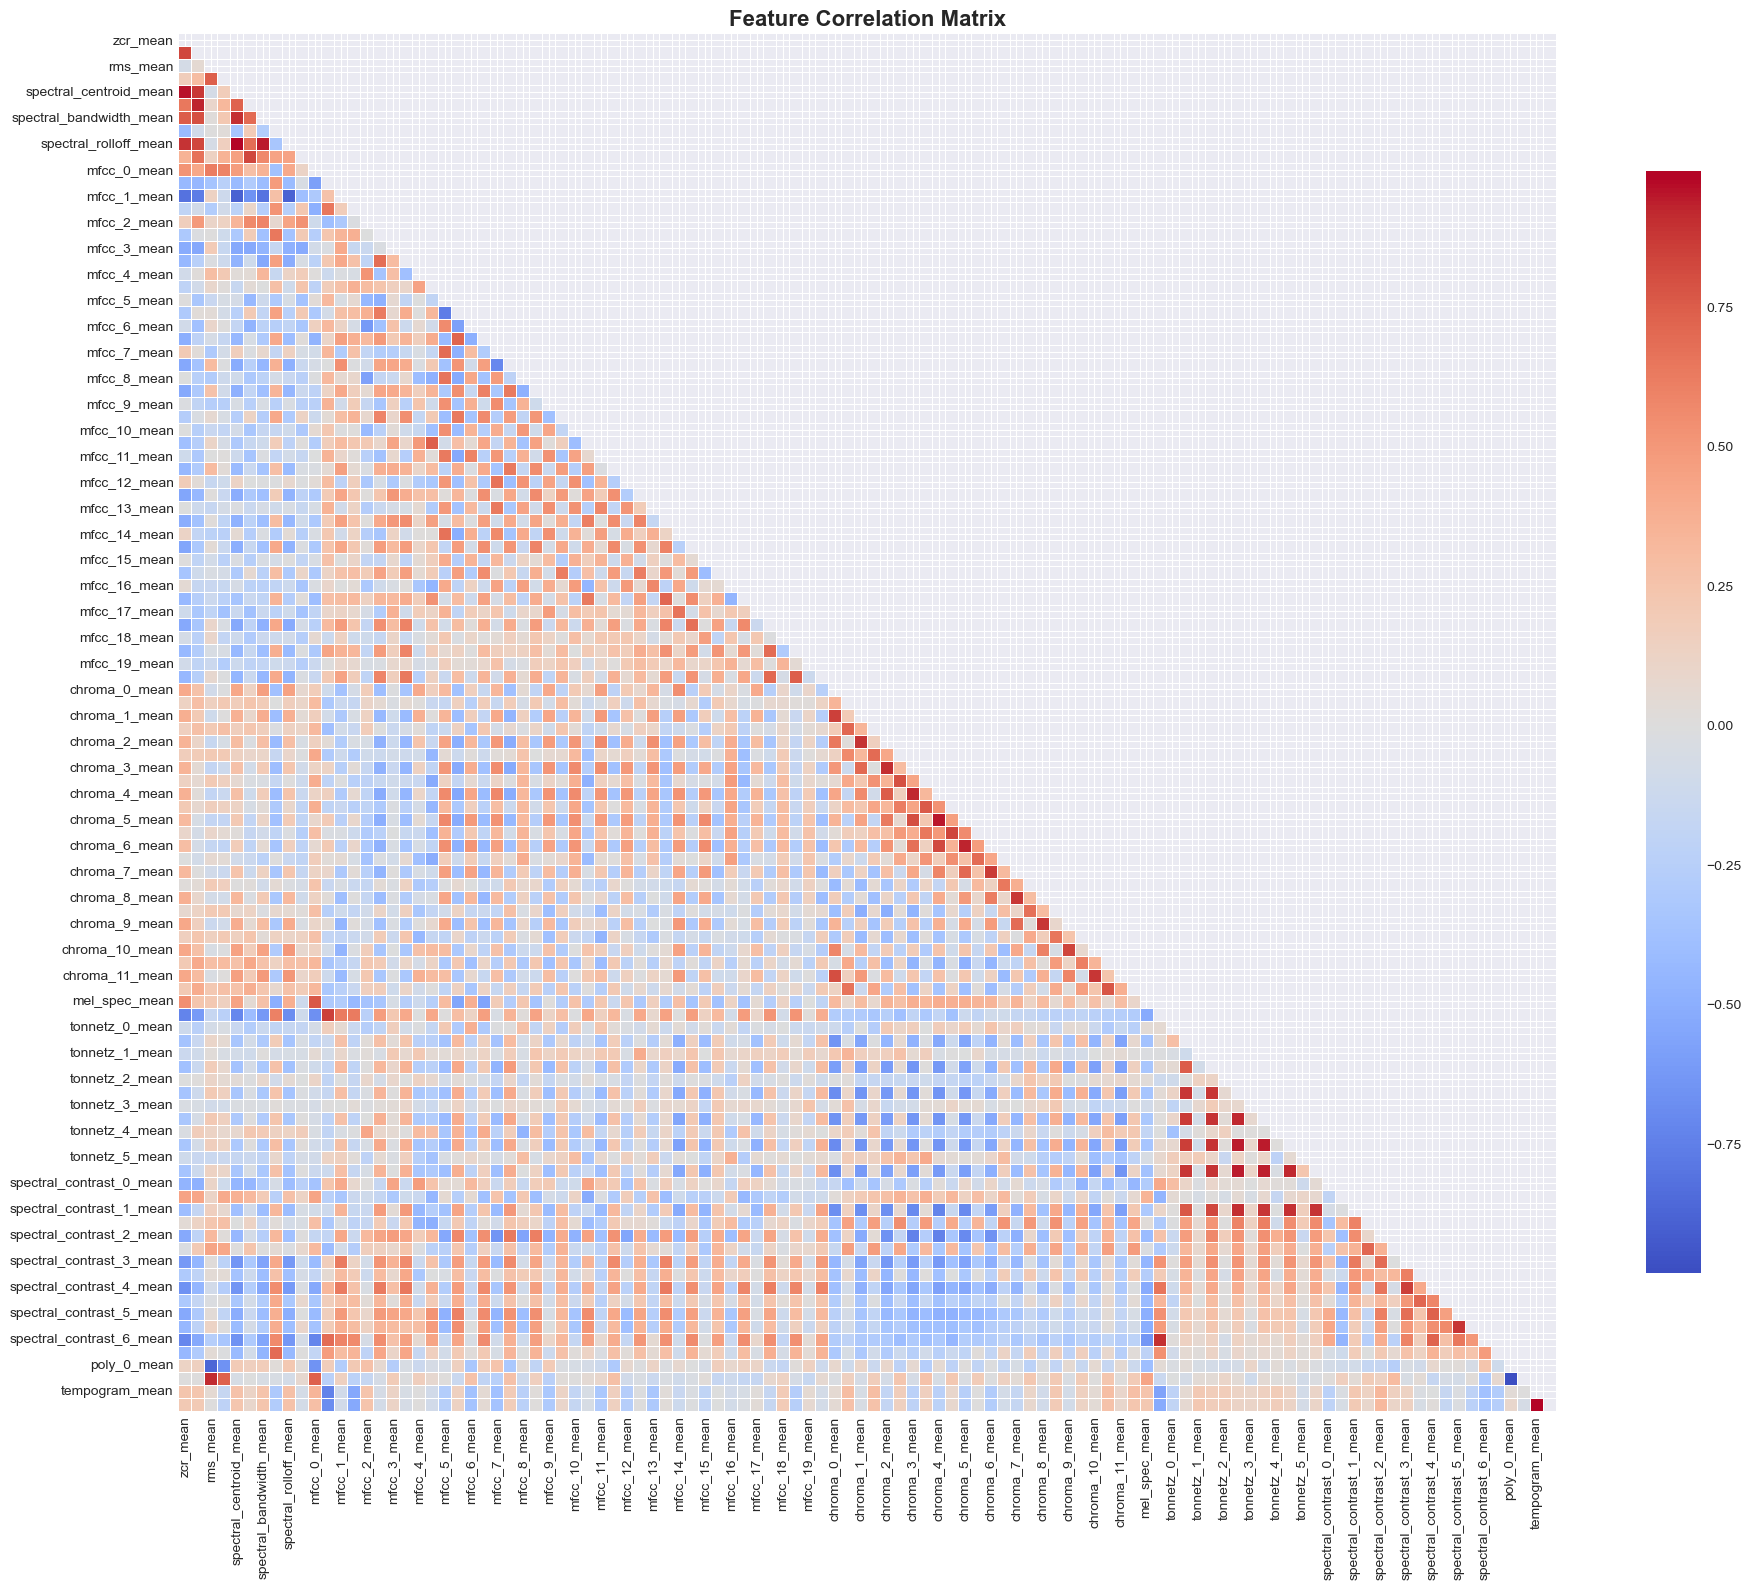

In [9]:
# Create feature correlation heatmap
plt.figure(figsize=(20, 16))
numeric_cols = features_df.select_dtypes(include=[np.number]).columns
corr_matrix = features_df[numeric_cols].corr()

# Plot only upper triangle
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, cmap='coolwarm', center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Feature Correlation Matrix', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('./Data_Cleaning_and_Feature_Extraction/feature_correlation.png', dpi=300, bbox_inches='tight')
plt.show()

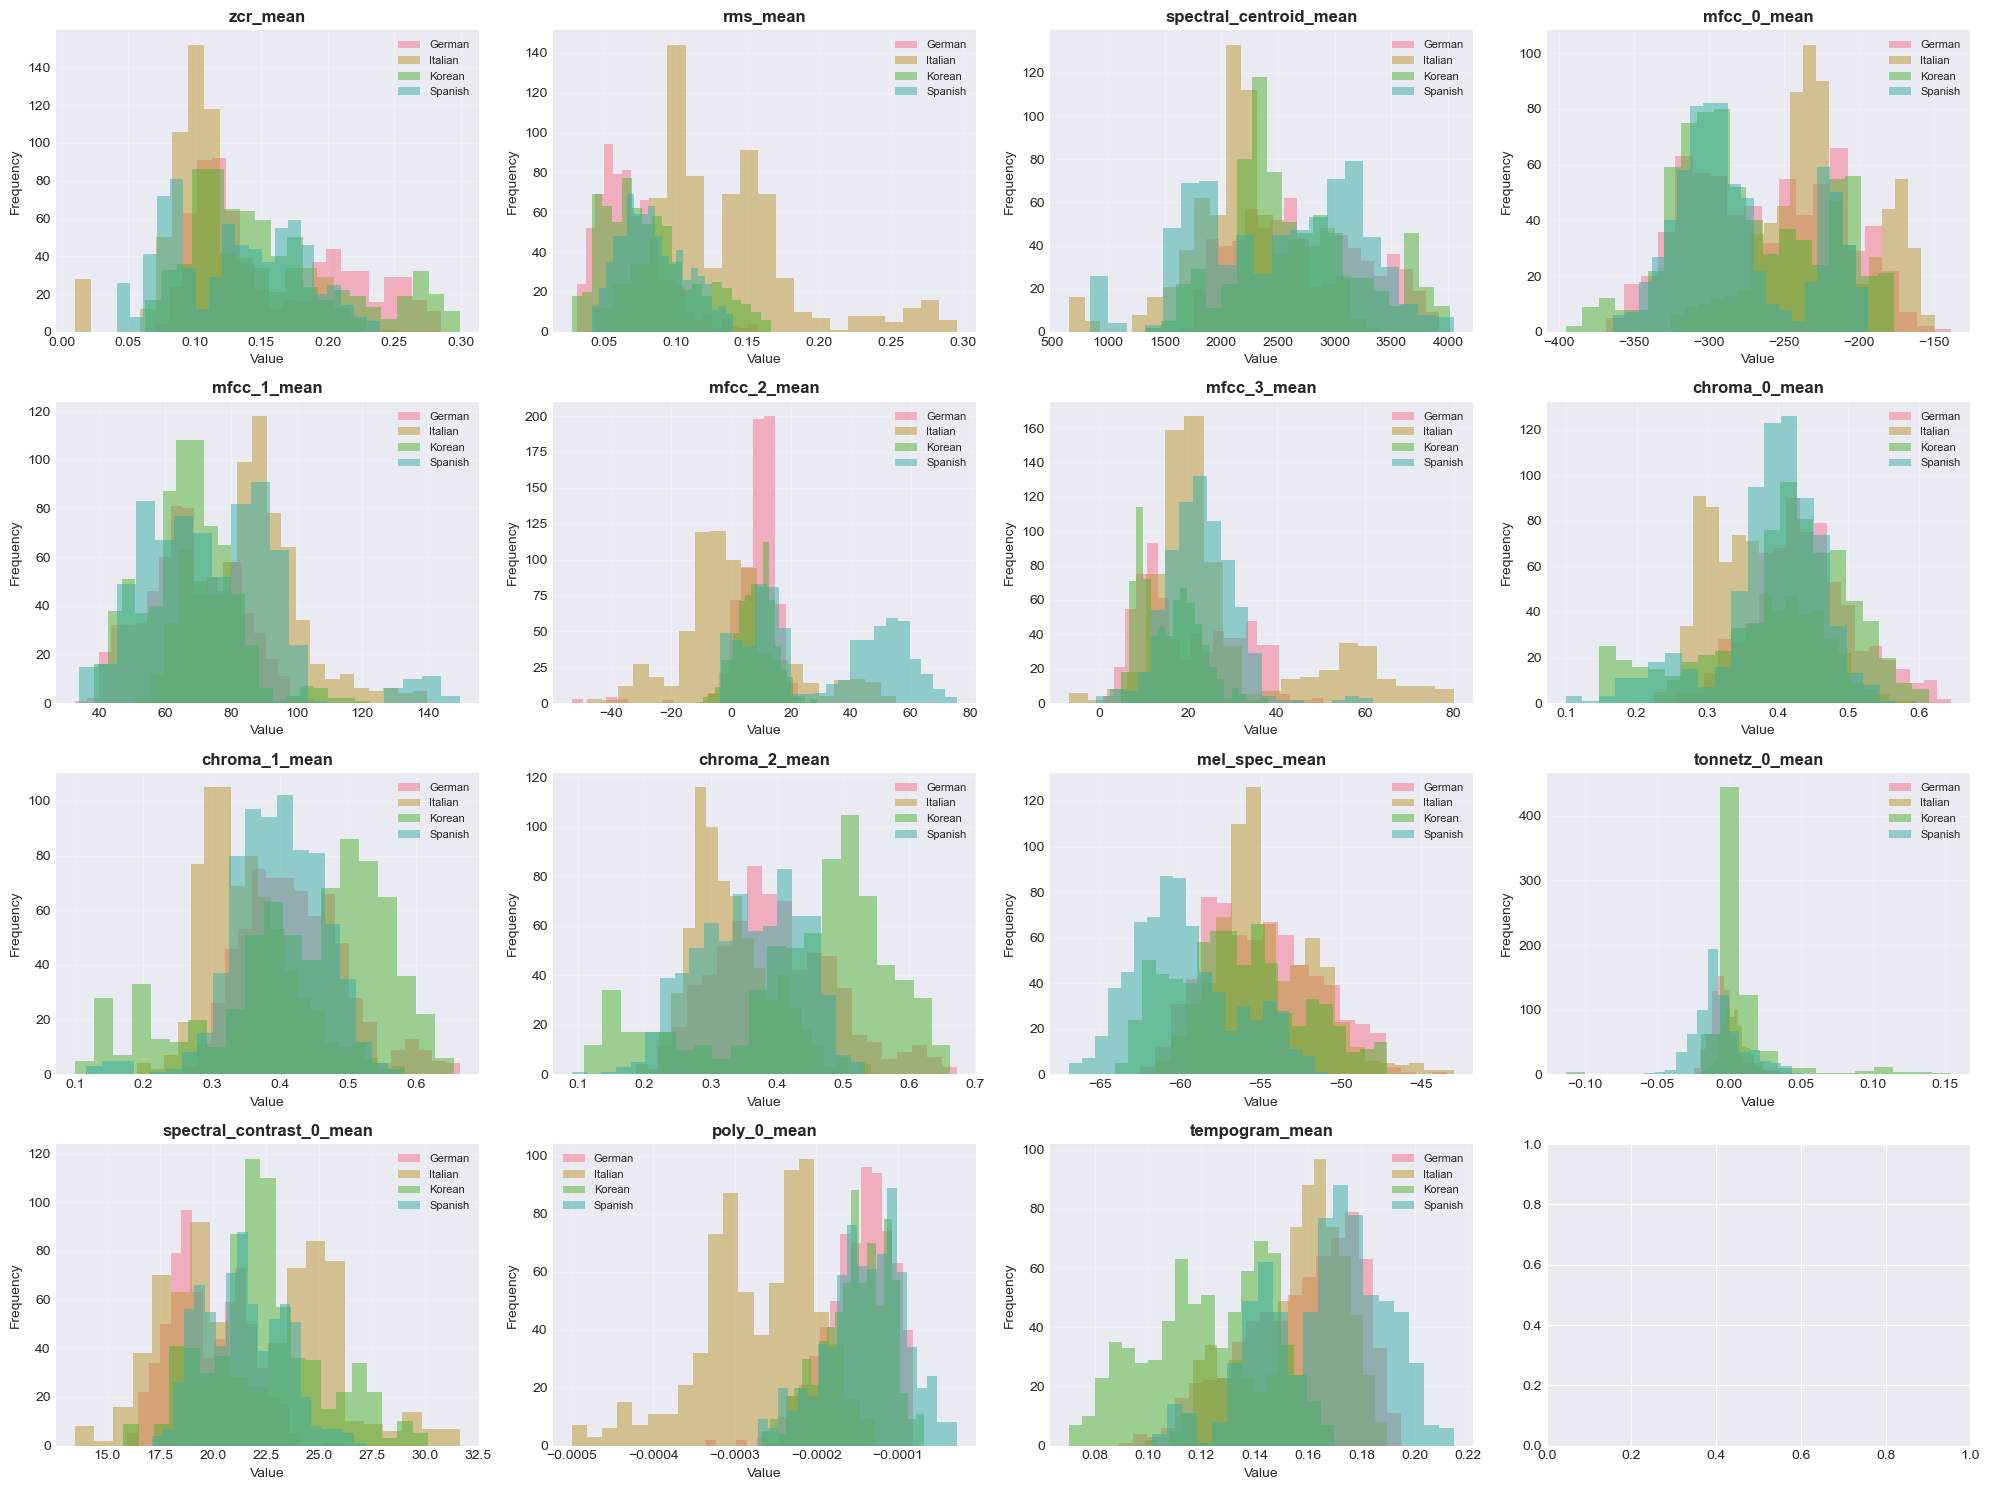

In [11]:
# Visualize feature distributions by language
def plot_feature_distributions():
    fig, axes = plt.subplots(4, 4, figsize=(20, 15))
    features_to_plot = ['zcr_mean', 'rms_mean', 'spectral_centroid_mean', 
                       'mfcc_0_mean', 'mfcc_1_mean', 'mfcc_2_mean', 'mfcc_3_mean',
                       'chroma_0_mean', 'chroma_1_mean', 'chroma_2_mean',
                       'mel_spec_mean', 'tonnetz_0_mean', 'spectral_contrast_0_mean',
                       'poly_0_mean', 'tempogram_mean']
    
    for idx, feature in enumerate(features_to_plot[:16]):
        ax = axes[idx//4, idx%4]
        for lang in LANGUAGES:
            data = features_df[features_df['language'] == lang][feature]
            ax.hist(data, alpha=0.5, label=lang, bins=20)
        
        ax.set_title(feature, fontweight='bold')
        ax.set_xlabel('Value')
        ax.set_ylabel('Frequency')
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('./Data_Cleaning_and_Feature_Extraction/feature_distributions.png', dpi=300, bbox_inches='tight')
    plt.show()

plot_feature_distributions()


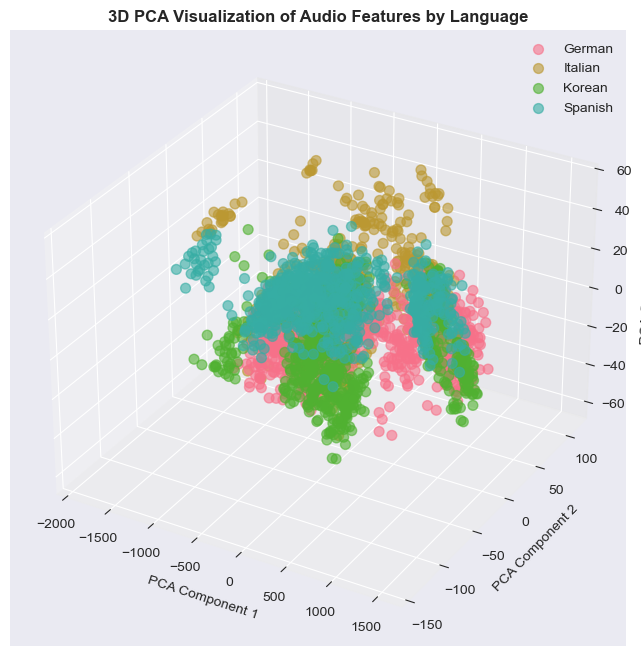

In [12]:
# Select key features
key_features = ['mfcc_0_mean', 'mfcc_1_mean', 'mfcc_2_mean', 
                'spectral_centroid_mean', 'zcr_mean', 'rms_mean',
                'chroma_0_mean', 'chroma_1_mean']

X_key = features_df[key_features]

# Apply PCA for 3D visualization
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_key)

# Create 3D plot
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

colors = {'German': 'red', 'Italian': 'blue', 'Korean': 'green', 'Spanish': 'purple'}
for lang in LANGUAGES:
    indices = features_df['language'] == lang
    ax.scatter(X_pca[indices, 0], X_pca[indices, 1], X_pca[indices, 2],
              label=lang, alpha=0.6, s=50)

ax.set_xlabel('PCA Component 1')
ax.set_ylabel('PCA Component 2')
ax.set_zlabel('PCA Component 3')
ax.set_title('3D PCA Visualization of Audio Features by Language', fontweight='bold')
ax.legend()
plt.savefig('./Data_Cleaning_and_Feature_Extraction/3d_pca_visualization.png', dpi=300, bbox_inches='tight')
plt.show()

<div style="
    display: flex;
    justify-content: space-between;
    align-items: center;
    padding: 30px 40px ;
    background-color: #ffffff;
    border-radius: 12px;
    box-shadow: 0 4px 12px rgba(0,0,0,0.08);
    margin-bottom: 20px;
    color: #555;
    font-size: 20px;
">
🔚 Summary Statistics
</div>

Summary Statistics for Key Features:
       mfcc_0_mean  mfcc_1_mean  mfcc_2_mean  spectral_centroid_mean  \
count  2848.000000  2848.000000  2848.000000             2848.000000   
mean   -261.050303    73.784639    11.953784             2517.308455   
std      48.771715    17.900835    18.982543              621.803191   
min    -395.681274    32.414619   -53.115211              652.554088   
25%    -301.892982    61.862333     2.087164             2099.255637   
50%    -262.908890    72.157341     9.467675             2449.709255   
75%    -221.262259    85.468287    15.046071             2971.142982   
max    -138.636228   149.811905    75.489853             4054.466849   

          zcr_mean     rms_mean  chroma_0_mean  chroma_1_mean  
count  2848.000000  2848.000000    2848.000000    2848.000000  
mean      0.140298     0.092063       0.399376       0.400352  
std       0.054443     0.041073       0.084726       0.092497  
min       0.009853     0.028068       0.099858       0.099

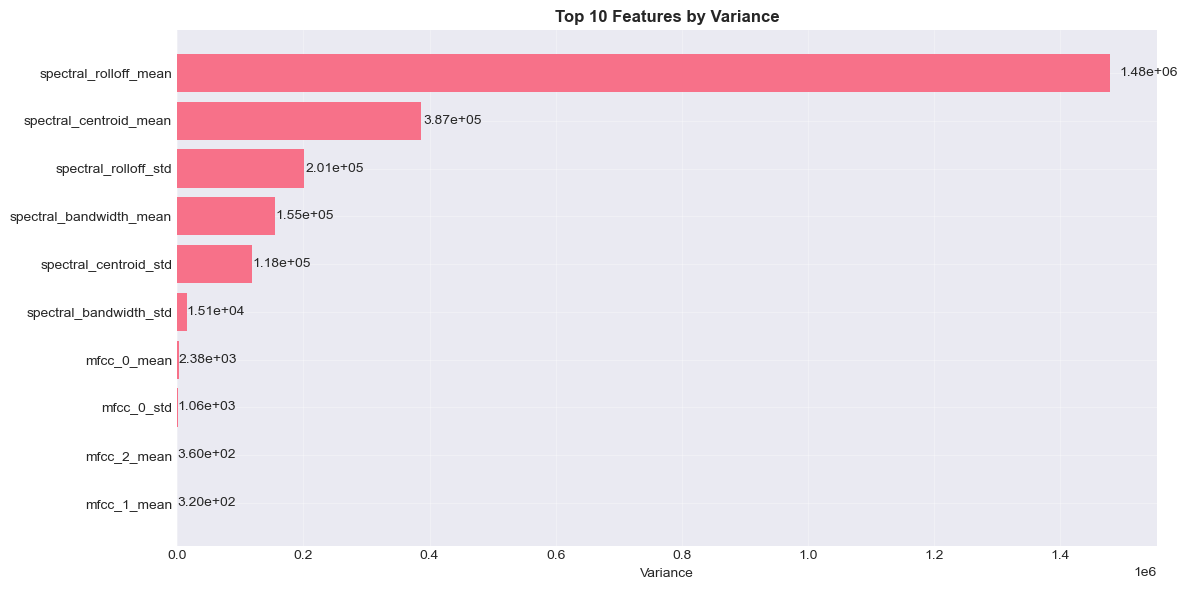

Total samples: 2848
Features per sample: 106


In [13]:
print("Summary Statistics for Key Features:")
print(features_df[key_features].describe())

# Feature importance using variance
feature_variance = features_df[numeric_cols].var().sort_values(ascending=False)
top_10_features = feature_variance.head(10)

plt.figure(figsize=(12, 6))
bars = plt.barh(top_10_features.index, top_10_features.values)
plt.gca().invert_yaxis()
plt.xlabel('Variance')
plt.title('Top 10 Features by Variance', fontweight='bold')
plt.grid(True, alpha=0.3)

# Add value labels
for bar in bars:
    width = bar.get_width()
    plt.text(width * 1.01, bar.get_y() + bar.get_height()/2,
             f'{width:.2e}', ha='left', va='center')

plt.tight_layout()
plt.savefig('./Data_Cleaning_and_Feature_Extraction/feature_variance.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Total samples: {len(features_df)}")
print(f"Features per sample: {len(features_df.columns) - 3}")